Directory 'output' already exists.
Directory 'plots' already exists.


<Figure size 640x480 with 0 Axes>

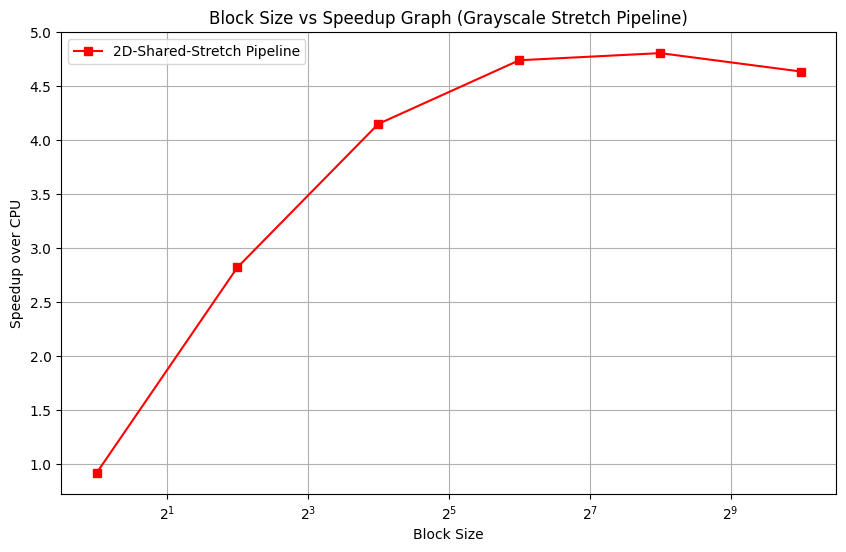

In [13]:
# HPC Labwork 7 : Reduction
# by Lucien Elyas Bedrane - 2640012

#!pip install numba

import numba
import matplotlib.pyplot as plt
import numpy as np
import time
import os

from numba import cuda

@numba.jit(nopython=True)
def grayscale_stretch_CPU(src_flat, img_shape):
    # Allocate sequential workspace for the pipeline steps
    dst_gray = np.zeros(len(src_flat) // 3, dtype=np.float32)

    # 1. Convert image to gray (MAP)
    idx_gray = 0
    for i in range(0, len(src_flat), 3):
        # Average color channels matching the GPU logic scale
        dst_gray[idx_gray] = (src_flat[i] + src_flat[i+1] + src_flat[i+2]) / 3.0
        idx_gray += 1

    # 2. Find max/min intensity of image (REDUCE)
    img_min = dst_gray[0]
    img_max = dst_gray[0]
    for i in range(1, len(dst_gray)):
        val = dst_gray[i]
        if val < img_min:
            img_min = val
        if val > img_max:
            img_max = val

    # 3. Linearly recalculate intensity for each pixel (MAP)
    dst_stretched = np.zeros(len(src_flat), dtype=np.uint8)
    idx_gray = 0
    for i in range(0, len(src_flat), 3):
        g = dst_gray[idx_gray]
        if img_max == img_min:
            new_g = np.uint8(0)
        else:
            new_g = np.uint8(((g - img_min) / (img_max - img_min)) * 255.0)

        dst_stretched[i] = dst_stretched[i+1] = dst_stretched[i+2] = new_g
        idx_gray += 1

    return np.reshape(dst_stretched, img_shape)

#We define the 2D GPU version of converting an image to a gray one using shared memory (MAP)
@cuda.jit
def grayscale_GPU_2D_shared_map(src, dst_gray):
    s_pixels = cuda.shared.array(shape=0, dtype=numba.float32)

    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y
    tidx = tx + cuda.blockIdx.x * cuda.blockDim.x
    tidy = ty + cuda.blockIdx.y * cuda.blockDim.y

    height, width, channels = src.shape
    local_idx = (ty * cuda.blockDim.x + tx) * 3

    if tidy < height and tidx < width:
        s_pixels[local_idx]     = src[tidy, tidx, 0]
        s_pixels[local_idx + 1] = src[tidy, tidx, 1]
        s_pixels[local_idx + 2] = src[tidy, tidx, 2]

    cuda.syncthreads()

    if tidy < height and tidx < width:
        # Image scaling is already handled cleanly on host memory
        g = (s_pixels[local_idx] + s_pixels[local_idx + 1] + s_pixels[local_idx + 2]) / 3.0
        dst_gray[tidy, tidx] = g

#We define the 2D GPU version of linearly recalculating intensity for each pixel (MAP)
@cuda.jit
def stretch_2D_map(gray_src, dst, img_min, img_max):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    height, width = gray_src.shape

    if tidy < height and tidx < width:
        g = gray_src[tidy, tidx]
        if img_max == img_min:
            new_g = np.uint8(0)
        else:
            res = ((g - img_min) / (img_max - img_min)) * 255.0
            # Clamp values to prevent out-of-bounds float casting inside uint8 registers
            if res < 0.0: res = 0.0
            if res > 255.0: res = 255.0
            new_g = np.uint8(res)
        dst[tidy, tidx, 0] = dst[tidy, tidx, 1] = dst[tidy, tidx, 2] = new_g

#We create folders the different outputs that we will generate
for directory_name in ["output", "plots"] :
  try:
      os.mkdir("/content/sample_data/" + directory_name)
      print(f"Directory '{directory_name}' created successfully.")
  except FileExistsError:
      print(f"Directory '{directory_name}' already exists.")
  except PermissionError:
      print(f"Permission denied: Unable to create '{directory_name}'.")
  except Exception as e:
      print(f"An error occurred: {e}")

#We load here the source image and flatten it to a 1D-array
img = plt.imread('/content/sample_data/lake.png')
if img.shape[2] == 4:
    img = img[:, :, :3]

# Store the scale baseline before flattening for consistency check
if img.max() <= 1.0:
    img_scaled = (img * 255.0).astype(np.float32)
else:
    img_scaled = img.astype(np.float32)

image_src = np.reshape(img_scaled, (-1, 3))
pixelCount = image_src.shape

#We initialize the blockSize and gridSize that will be used to test the 2D GPU version of grayscale
blockSize2D = [(2**x, 2**x) for x in range(6)]
gridSize2D = [(int(np.ceil(img.shape[1] / x[0])), int(np.ceil(img.shape[0] / x[1]))) for x in blockSize2D]

devSrc2D = cuda.to_device(img_scaled)
time_records_2D_shared = []

#In this loop, we try the GPU version of grayscale stretch with shared memory using different size of blocks and grids
for i in range(len(blockSize2D)):
    devIntermediateGray = cuda.device_array((img.shape[0], img.shape[1]), dtype=np.float32)
    devStretchedDst2D = cuda.device_array(img.shape, np.uint8)

    # Calculate bytes dynamically using arithmetic element multiplication
    sharedSize = blockSize2D[i][0] * blockSize2D[i][1] * 3 * 4

    cuda.synchronize()
    start_time = time.time()

    # 1. Convert image to gray (MAP) using full 2D block tuples
    grayscale_GPU_2D_shared_map[gridSize2D[i], blockSize2D[i], 0, sharedSize](devSrc2D, devIntermediateGray)

    # 2. Find max/min intensity of image (REDUCE via host NumPy)
    h_gray = devIntermediateGray.copy_to_host()
    global_min = np.min(h_gray)
    global_max = np.max(h_gray)

    # 3. Linearly recalculate intensity for each pixel (MAP)
    stretch_2D_map[gridSize2D[i], blockSize2D[i]](devIntermediateGray, devStretchedDst2D, global_min, global_max)

    hostDst2D = devStretchedDst2D.copy_to_host()
    cuda.synchronize()
    end_time = time.time()

    time_records_2D_shared.append(end_time - start_time)
    plt.imsave("/content/sample_data/output/gpu_2D_shared_stretched_" + str(i) + ".png", hostDst2D)

#We use the CPU version of grayscale stretch complete pipeline
image_src_flat = image_src.flatten()
start_time_cpu = time.time()
cpu_image = grayscale_stretch_CPU(image_src_flat, img.shape)
end_time_cpu = time.time()
time_cpu = end_time_cpu - start_time_cpu

plt.imsave("/content/sample_data/output/cpu_output.png", cpu_image)

#We compute the speedup for each version compared to the CPU version
speedup_2D_shared = [time_cpu / t for t in time_records_2D_shared]

#We plot and save the graph of Block Size vs Speedup
plt.clf()
plt.figure(figsize=(10, 6))
plt.xscale('log', base=2)
plt.plot([x[0]**2 for x in blockSize2D], speedup_2D_shared, linestyle="-", color="red", marker="s", label="2D-Shared-Stretch Pipeline")
plt.legend()
plt.title("Block Size vs Speedup Graph (Grayscale Stretch Pipeline)")
plt.xlabel("Block Size")
plt.ylabel("Speedup over CPU")
plt.grid(True)
plt.savefig("/content/sample_data/plots/BlockSize_vs_Speedup_Graph.png")
